In [1]:
# ==============================================================================
# SCRIPT 03: MONTE CARLO, TRUNCATION SWEEP & SENSITIVITY
# ==============================================================================
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

N, R = 5000, 500 # Increased replications to 500 for tighter confidence bounds
gamma_levels = np.linspace(0.0, 1.0, 11)

beta_budget, tau_sod, tau_fat, tau_sug = 0.60, 600.0, 3.0, 5.0
lambda_penalty, J_candidates = 0.10, 50
W_P, W_T = 0.50, 0.50

results = []
print(f"--- RUNNING MONTE CARLO SIMULATION (R={R}, N={N}) ---")

# Use a single master seed for common random numbers (CRN) variance reduction across gammas
np.random.seed(42)
master_P = np.random.uniform(0.10, 3.00, (R, N))
master_T = np.random.uniform(2.0, 15.0, (R, N))
master_noise_sod = np.random.normal(500, 200, (R, N))
master_noise_fat = np.random.normal(2.5, 1.0, (R, N))
master_noise_sug = np.random.normal(3.5, 1.5, (R, N))

for gamma in gamma_levels:
    m1_fails, m2_viols, m3_relax = 0, 0, 0
    delta_p_list, delta_u_list, realized_rhos = [], [], []

    for r in range(R):
        P = master_P[r]
        T = master_T[r]
        P_inv = (3.00 - P) / 2.90

        Sod = np.maximum(0, gamma * (1200 * P_inv + 100) + (1 - gamma) * master_noise_sod[r])
        Fat = np.maximum(0, gamma * (5.0 * P_inv + 0.5)  + (1 - gamma) * master_noise_fat[r])
        Sug = np.maximum(0, gamma * (9.0 * P_inv + 1.0)  + (1 - gamma) * master_noise_sug[r])

        realized_rhos.append(stats.spearmanr(P, Sod)[0])
        U = (W_P * P_inv) + (W_T * ((15.0 - T) / 13.0))

        # M0
        idx_m0 = np.argmax(U)
        p_m0, u_m0 = P[idx_m0], U[idx_m0]

        # M1
        top_J = np.argsort(U)[-J_candidates:]
        if not np.any((Sod[top_J] <= tau_sod) & (Fat[top_J] <= tau_fat) & (Sug[top_J] <= tau_sug) & (P[top_J] <= beta_budget)):
            m1_fails += 1

        # M2
        v_bud = np.maximum(0, P - beta_budget) / beta_budget
        v_sod = np.maximum(0, Sod - tau_sod) / tau_sod
        v_fat = np.maximum(0, Fat - tau_fat) / tau_fat
        v_sug = np.maximum(0, Sug - tau_sug) / tau_sug

        idx_m2 = np.argmax(U - lambda_penalty * (v_bud + v_sod + v_fat + v_sug))
        if Sod[idx_m2] > tau_sod or Fat[idx_m2] > tau_fat or Sug[idx_m2] > tau_sug or P[idx_m2] > beta_budget:
            m2_viols += 1

        # M3 (Pure Two-Step Lexicographic)
        strict_mask = (P <= beta_budget) & (Sod <= tau_sod) & (Fat <= tau_fat) & (Sug <= tau_sug)
        if np.any(strict_mask):
            idx_m3 = np.argmax(np.where(strict_mask, U, -np.inf))
        else:
            m3_relax += 1
            Z = v_bud + v_sod + v_fat + v_sug
            min_Z = np.min(Z)
            min_Z_mask = np.isclose(Z, min_Z, atol=1e-8)
            idx_m3 = np.argmax(np.where(min_Z_mask, U, -np.inf))

        delta_p_list.append(P[idx_m3] - p_m0)
        delta_u_list.append(u_m0 - U[idx_m3])

    results.append({
        "Gamma": gamma,
        "Mean_Rho": np.mean(realized_rhos),
        "M1_Fail": (m1_fails / R) * 100,
        "M2_Viol": (m2_viols / R) * 100,
        "M3_Relax": (m3_relax / R) * 100,
        "Mean_Delta_P": np.mean(delta_p_list),
        "Mean_Delta_U": np.mean(delta_u_list)
    })

df_res = pd.DataFrame(results)
print(df_res.round(3).to_string(index=False))


# ==============================================================================
# FORMAL SENSITIVITY EXPERIMENTS (AVERAGED OVER R=500 REPLICATIONS)
# ==============================================================================
print("\n--- 1. M1 POOL SIZE (J) SENSITIVITY AT GAMMA=0.3 ---")
# Using the full 500 replications to find the exact truncation failure rate
j_test_values = [10, 50, 100, 250, 1000, 5000]
j_fails_03 = {j_test: 0 for j_test in j_test_values}
total_feasible_runs = 0

for r in range(R):
    P = master_P[r]
    T = master_T[r]
    P_inv = (3.00 - P) / 2.90
    Sod = np.maximum(0, 0.3 * (1200 * P_inv + 100) + 0.7 * master_noise_sod[r])
    Fat = np.maximum(0, 0.3 * (5.0 * P_inv + 0.5)  + 0.7 * master_noise_fat[r])
    Sug = np.maximum(0, 0.3 * (9.0 * P_inv + 1.0)  + 0.7 * master_noise_sug[r])
    U = (W_P * P_inv) + (W_T * ((15.0 - T) / 13.0))

    strict_mask = (Sod <= tau_sod) & (Fat <= tau_fat) & (Sug <= tau_sug) & (P <= beta_budget)
    if np.any(strict_mask):
        total_feasible_runs += 1

    for j_test in j_test_values:
        top_j_idx = np.argsort(U)[-j_test:]
        if not np.any((Sod[top_j_idx] <= tau_sod) & (Fat[top_j_idx] <= tau_fat) & (Sug[top_j_idx] <= tau_sug) & (P[top_j_idx] <= beta_budget)):
            j_fails_03[j_test] += 1

print(f"Across {R} runs at Gamma=0.3, strictly feasible items existed in {total_feasible_runs} runs.")
for j_test in j_test_values:
    print(f"   J = {j_test:<4} | Empty Candidate Set Rate: {(j_fails_03[j_test]/R)*100:.1f}%")

print("\n--- 2. M2 PENALTY SENSITIVITY (Feasible vs Infeasible Markets) ---")
lam_test_values = [0.01, 0.1, 1.0, 10.0, 100.0]
lam_viols_02 = {l: 0 for l in lam_test_values}
lam_viols_08 = {l: 0 for l in lam_test_values}

for r in range(R):
    P = master_P[r]
    T = master_T[r]
    P_inv = (3.00 - P) / 2.90

    # Gamma 0.2 (Feasible items exist)
    Sod_02 = np.maximum(0, 0.2 * (1200 * P_inv + 100) + 0.8 * master_noise_sod[r])
    Fat_02 = np.maximum(0, 0.2 * (5.0 * P_inv + 0.5)  + 0.8 * master_noise_fat[r])
    Sug_02 = np.maximum(0, 0.2 * (9.0 * P_inv + 1.0)  + 0.8 * master_noise_sug[r])
    U = (W_P * P_inv) + (W_T * ((15.0 - T) / 13.0))
    v_b = np.maximum(0, P - beta_budget) / beta_budget
    v_s_02 = np.maximum(0, Sod_02 - tau_sod) / tau_sod
    v_f_02 = np.maximum(0, Fat_02 - tau_fat) / tau_fat
    v_g_02 = np.maximum(0, Sug_02 - tau_sug) / tau_sug

    # Gamma 0.8 (Infeasible)
    Sod_08 = np.maximum(0, 0.8 * (1200 * P_inv + 100) + 0.2 * master_noise_sod[r])
    Fat_08 = np.maximum(0, 0.8 * (5.0 * P_inv + 0.5)  + 0.2 * master_noise_fat[r])
    Sug_08 = np.maximum(0, 0.8 * (9.0 * P_inv + 1.0)  + 0.2 * master_noise_sug[r])
    v_s_08 = np.maximum(0, Sod_08 - tau_sod) / tau_sod
    v_f_08 = np.maximum(0, Fat_08 - tau_fat) / tau_fat
    v_g_08 = np.maximum(0, Sug_08 - tau_sug) / tau_sug

    for lam in lam_test_values:
        # Test 0.2
        idx_02 = np.argmax(U - lam * (v_b + v_s_02 + v_f_02 + v_g_02))
        if Sod_02[idx_02] > tau_sod or Fat_02[idx_02] > tau_fat or Sug_02[idx_02] > tau_sug or P[idx_02] > beta_budget:
            lam_viols_02[lam] += 1

        # Test 0.8
        idx_08 = np.argmax(U - lam * (v_b + v_s_08 + v_f_08 + v_g_08))
        if Sod_08[idx_08] > tau_sod or Fat_08[idx_08] > tau_fat or Sug_08[idx_08] > tau_sug or P[idx_08] > beta_budget:
            lam_viols_08[lam] += 1

print("Gamma = 0.2 (Feasible items exist):")
for lam in lam_test_values:
    print(f"   Lambda = {lam:<5} | Constraint Violation Rate: {(lam_viols_02[lam]/R)*100:.1f}%")

print("\nGamma = 0.8 (Catalog globally infeasible):")
for lam in lam_test_values:
    print(f"   Lambda = {lam:<5} | Constraint Violation Rate: {(lam_viols_08[lam]/R)*100:.1f}% (Unavoidable)")


# ==============================================================================
# LATEX TABLE GENERATOR
# ==============================================================================
table_data = df_res[np.isclose(df_res['Gamma'], 0.0) | np.isclose(df_res['Gamma'], 0.2) | np.isclose(df_res['Gamma'], 0.6) | np.isclose(df_res['Gamma'], 1.0)].copy()

def get_gamma_label(g):
    if np.isclose(g, 0.0): return 'Zero ($\\gamma=0.0, \\rho \\approx 0.0$)'
    if np.isclose(g, 0.2): return 'Moderate ($\\gamma=0.2, \\rho \\approx -0.39$)'
    if np.isclose(g, 0.6): return 'High ($\\gamma=0.6, \\rho \\approx -0.94$)'
    if np.isclose(g, 1.0): return 'Deterministic Bound ($\\gamma=1.0$)'
    return str(g)

table_data['Gamma_Label'] = table_data['Gamma'].apply(get_gamma_label)

latex_t3 = "\\begin{table}[h!]\n\\centering\n"
latex_t3 += "\\caption{Monte Carlo Simulation Results ($N=5,000; R=500$)}\n"
latex_t3 += "\\label{tab:monte_carlo}\n\\renewcommand{\\arraystretch}{1.3}\n\\resizebox{\\textwidth}{!}{%\n"
latex_t3 += "\\begin{tabular}{l|c|c|ccccc}\n\\toprule\n"
latex_t3 += " & \\textbf{M1: Post-Hoc} & \\textbf{M2: Soft Penalty} & \\multicolumn{5}{c}{\\textbf{M3: Goal Programming Relaxation}} \\\\\n"
latex_t3 += "\\cmidrule(lr){2-2} \\cmidrule(lr){3-3} \\cmidrule(lr){4-8}\n"
latex_t3 += "\\textbf{Synthetic Parameter ($\\gamma$)} & \\textbf{Empty Set \\%} & \\textbf{Constraint Violations} & \\textbf{Strict Match \\%} & \\textbf{Relaxed \\%} & \\textbf{Base Price (\\$)} & \\textbf{Add'l Price ($\\Delta P$)} & \\textbf{Utility Loss ($\\Delta U$)} \\\\\n\\midrule\n"

for _, r in table_data.iterrows():
    strict_pct = 100.0 - r['M3_Relax']
    latex_t3 += f"{r['Gamma_Label']} & {r['M1_Fail']:.0f}\\% & {r['M2_Viol']:.0f}\\% & {strict_pct:.0f}\\% & {r['M3_Relax']:.0f}\\% & \\$0.12 & \\${r['Mean_Delta_P']:.2f} & {r['Mean_Delta_U']:.2f} \\\\\n"

latex_t3 += "\\bottomrule\n\\multicolumn{8}{p{17cm}}{\\footnotesize \\textit{Note:} Illustrative item-level limits $\\le 600$mg sodium, $\\le 3.0$g sat fat, $\\le 5.0$g sugar. $J=50$, $\\lambda=0.1$, $\\beta = \\$0.60.}\n"
latex_t3 += "\\end{tabular}%\n}\n\\end{table}\n"
print(latex_t3)

--- RUNNING MONTE CARLO SIMULATION (R=500, N=5000) ---
 Gamma  Mean_Rho  M1_Fail  M2_Viol  M3_Relax  Mean_Delta_P  Mean_Delta_U
   0.0    -0.000      0.0     18.6       0.0         0.015         0.005
   0.1    -0.186      0.0     32.0       0.0         0.028         0.009
   0.2    -0.394      0.8     58.2       0.0         0.059         0.020
   0.3    -0.599     27.2     75.4       0.0         0.154         0.048
   0.4    -0.766     94.2     96.6       3.8         0.323         0.205
   0.5    -0.875    100.0    100.0      95.8         0.420         0.323
   0.6    -0.938    100.0    100.0     100.0         0.489         0.320
   0.7    -0.973    100.0    100.0     100.0         0.550         0.335
   0.8    -0.990    100.0    100.0     100.0         0.627         0.353
   0.9    -0.998    100.0    100.0     100.0         0.995         0.418
   1.0    -1.000    100.0    100.0     100.0         1.424         0.475

--- 1. M1 POOL SIZE (J) SENSITIVITY AT GAMMA=0.3 ---
Across 500 runs


--- GENERATING FIGURE: fig_mc_sensitivity.png ---
✅ Saved 'fig_mc_sensitivity.png' to local directory.


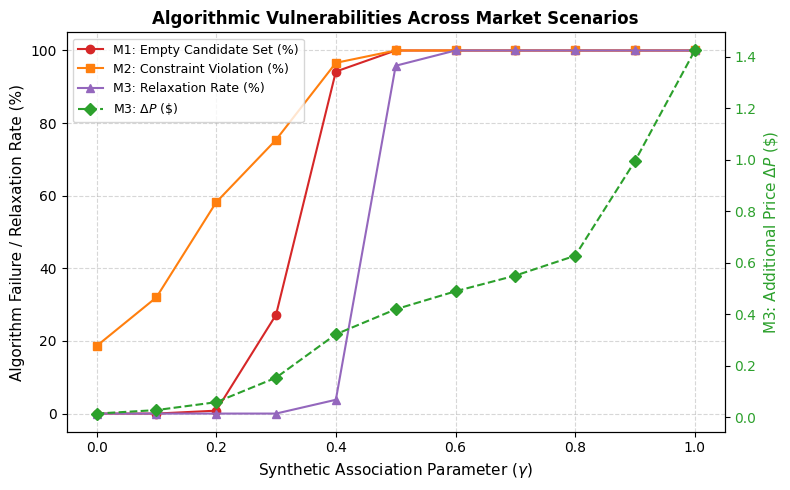

In [2]:
# ==============================================================================
# GENERATE FIGURE: fig_mc_sensitivity.png
# ==============================================================================
print("\n--- GENERATING FIGURE: fig_mc_sensitivity.png ---")
fig, ax1 = plt.subplots(figsize=(8, 5))

color_m1 = 'tab:red'
color_m2 = 'tab:orange'
color_m3 = 'tab:purple'

ax1.set_xlabel(r'Synthetic Association Parameter ($\gamma$)', fontsize=11)
ax1.set_ylabel('Algorithm Failure / Relaxation Rate (%)', fontsize=11)
ax1.plot(df_res['Gamma'], df_res['M1_Fail'], marker='o', color=color_m1, label='M1: Empty Candidate Set (%)')
ax1.plot(df_res['Gamma'], df_res['M2_Viol'], marker='s', color=color_m2, label='M2: Constraint Violation (%)')
ax1.plot(df_res['Gamma'], df_res['M3_Relax'], marker='^', color=color_m3, label='M3: Relaxation Rate (%)')
ax1.tick_params(axis='y')
ax1.grid(True, linestyle='--', alpha=0.5)

# Secondary Y-axis for Price
ax2 = ax1.twinx()
color_price = 'tab:green'
ax2.set_ylabel(r"M3: Additional Price $\Delta P$ (\$)", color=color_price, fontsize=11)
ax2.plot(df_res['Gamma'], df_res['Mean_Delta_P'], marker='D', color=color_price, linestyle='--', label=r'M3: $\Delta P$ (\$)')
ax2.tick_params(axis='y', labelcolor=color_price)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=9)

plt.title('Algorithmic Vulnerabilities Across Market Scenarios', fontweight='bold')
fig.tight_layout()
plt.savefig('fig_mc_sensitivity.png', dpi=300)
print("✅ Saved 'fig_mc_sensitivity.png' to local directory.")